In [49]:
# ============================================================================
# CELL 1: CONFIGURATION — Edit this cell for each run
# ============================================================================

MODEL="gemma-12b"
# MODEL="llama-3b"
DATASET="triviaqa"
# DATASET="hotpotqa"

# Main results file
RESULTS_CSV = f"adapters_results/{DATASET}/threshold_0.8/{MODEL}.csv"

# External benchmark files
BIGBENCH_CSV = f"adapters_results/{DATASET}/bigbench_summary.csv"
MMLU_CSV = f"adapters_results/{DATASET}/mmlu_summary.csv"

# Filtering
ACCURACY_THRESHOLD = 0.9        # Minimum accuracy for "qualified" configs
MIN_NEGATIVE_SHIFT = 0          # negative_shift_score > this value

# Size categorization thresholds
LORA_RANK_BINS = {1: 'Small', 3: 'Medium', 8: 'Medium', 16: 'Medium', 32: 'Large'}   # default -> 'Large'
UI_SVECS_BINS = [(0, 32, 'Small'), (64, 256, 'Medium'), (512, float('inf'), 'Large')]
VERA_DEFAULT_SIZE = 'Small'

# Plot settings
FIGURE_SIZE = (15, 10)
TYPE_COLORS = {'lora': '#1f77b4', 'uiortholora': '#2ca02c', 'vera': '#ff7f0e', 'dora': '#9467bd'}
BG_COLORS = {'Small': '#f0f8ff', 'Medium': '#f5f5f5', 'Large': '#fff0f5'}

# Plot title prefix (e.g. model name)
PLOT_TITLE_PREFIX = f"{MODEL} ({DATASET})"

In [50]:
# ============================================================================
# CELL 2: IMPORTS
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import re

In [51]:
# ============================================================================
# CELL 3: HELPER FUNCTIONS
# ============================================================================

def load_and_clean(path, accuracy_thresh, min_neg_shift):
    """Load main results CSV and apply basic cleaning/filtering."""
    df = pd.read_csv(path)
    for col in ["lr", "rank", "accuracy", "negative_shift_score"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df[(df['accuracy'].notna()) & (df['negative_shift_score'] > min_neg_shift)].copy()
    return df


def extract_config_details(row):
    """Parse adapter name into a human-readable label, rank, and svecs."""
    name = row['raw_adapter_name']
    adapter_type = row['adapter_type']

    if adapter_type == 'lora':
        match = re.search(r'lora_r(\d+)', name)
        rank = int(match.group(1)) if match else 0
        return f"LoRA r={rank}", rank, None
    elif adapter_type == 'uiortholora':
        # 1. Check for the newer format (e.g., sv1024_svec128)
        match_new = re.search(r'sv(\d+)_svec(\d+)', name)
        if match_new:
            svec_val = int(match_new.group(2))
            return f"UI-OrthoLoRA svec={svec_val}", None, svec_val
            
        # 2. Check for the older format (e.g., s1024_v32)
        match_old = re.search(r's(\d+)_v(\d+)', name)
        if match_old:
            v_val = int(match_old.group(2))
            return f"UI-OrthoLoRA v={v_val}", None, v_val
            
        # 3. Fallback if neither matches
        return "UI-LoRA", None, None
    elif adapter_type == 'vera':
        match = re.search(r'vera_r(\d+)', name)
        rank = int(match.group(1)) if match else 0
        return f"VeRA r={rank}", rank, None
    elif adapter_type == 'dora':
        match = re.search(r'lora_r(\d+)', name)
        rank = int(match.group(1)) if match else 0
        return f"DoRA r={rank}", rank, None
    return "Unknown", 0, None


def categorize_size(row, lora_bins, ui_bins, vera_default):
    """Assign a size category (Small/Medium/Large) based on adapter type and params."""
    adapter_type = row['adapter_type']
    svecs = row['svecs']
    rank = row['rank_val']

    if adapter_type == 'lora':
        return lora_bins.get(rank, 'Large')
    elif adapter_type == 'uiortholora':
        if svecs is not None:
            for low, high, label in ui_bins:
                if low <= svecs <= high:
                    return label
    elif adapter_type == 'vera':
        return vera_default
    return 'Medium'


def get_best_configs(df, accuracy_thresh):
    """Filter to qualified configs and pick the best (lowest neg shift) per config."""
    qualified = df[df['accuracy'] >= accuracy_thresh].copy()
    best = qualified.loc[
        qualified.groupby('config_label')['negative_shift_score'].idxmin()
    ].copy()
    return best


def attach_external_benchmarks(df, bigbench_path, mmlu_path):
    """Map BigBench and MMLU scores onto the best-config dataframe."""
    df_bb = pd.read_csv(bigbench_path)
    df_mm = pd.read_csv(mmlu_path)

    # Split by '/' and take the last part to get the pure adapter name
    df_bb['match_key'] = df_bb['model_path'].str.split('/').str[-1]
    df_mm['match_key'] = df_mm['model_name'].str.split('/').str[-1]

    bb_lookup = df_bb.set_index('match_key')['mean_accuracy'].to_dict()
    mm_lookup = df_mm.set_index('match_key')['mmlu_acc'].to_dict()

    # Ensure we are also comparing against just the pure adapter name in the main df
    df['match_key'] = df['raw_adapter_name'].str.split('/').str[-1]
    
    df['bigbench_acc'] = df['match_key'].map(bb_lookup)
    df['mmlu_acc'] = df['match_key'].map(mm_lookup)
    
    return df

In [52]:
# ============================================================================
# CELL 4: PROCESS DATA
# ============================================================================

df = load_and_clean(RESULTS_CSV, ACCURACY_THRESHOLD, MIN_NEGATIVE_SHIFT)

df[['config_label', 'rank_val', 'svecs']] = df.apply(
    lambda row: pd.Series(extract_config_details(row)), axis=1
)

df['size_category'] = df.apply(
    categorize_size, axis=1,
    lora_bins=LORA_RANK_BINS, ui_bins=UI_SVECS_BINS, vera_default=VERA_DEFAULT_SIZE
)

best_per_config = get_best_configs(df, ACCURACY_THRESHOLD)
best_per_config = attach_external_benchmarks(best_per_config, BIGBENCH_CSV, MMLU_CSV)

print(f"Total rows after filtering: {len(df)}")
print(f"Qualified configs (acc >= {ACCURACY_THRESHOLD}): {len(best_per_config)}")
best_per_config[['config_label', 'size_category', 'accuracy', 'negative_shift_score', 'bigbench_acc', 'mmlu_acc']]

Total rows after filtering: 124
Qualified configs (acc >= 0.9): 19


,config_label,size_category,accuracy,negative_shift_score,bigbench_acc,mmlu_acc
3,DoRA r=1,Medium,0.997108,8825.1,0.458279,0.570788
2,DoRA r=16,Medium,0.997665,7604.5,0.460304,0.603831
5,DoRA r=3,Medium,0.996932,8158.0,0.451682,0.590870
4,DoRA r=32,Medium,0.996820,7746.0,0.467139,0.602549
6,DoRA r=8,Medium,0.997171,8114.3,0.468113,0.600769
58,LoRA r=0,Large,0.993429,9013.3,0.599143,0.699473
29,LoRA r=1,Small,0.995667,8920.3,0.610607,0.691426
28,LoRA r=16,Medium,0.997108,7638.8,0.636582,0.704529
31,LoRA r=3,Medium,0.996341,8368.8,0.634950,0.698120
30,LoRA r=32,Large,0.996834,7851.8,0.646061,0.709372


In [53]:
# ============================================================================
# CELL 5: PLOTTING FUNCTIONS
# ============================================================================

def prepare_plot_df(best_df, type_colors):
    """Sort by size then score and assign colors."""
    size_order = {'Small': 0, 'Medium': 1, 'Large': 2}
    best_df = best_df.copy()
    best_df['size_rank'] = best_df['size_category'].map(size_order)
    best_df = best_df.sort_values(by=['size_rank', 'negative_shift_score'], ascending=[True, False])
    best_df['color'] = best_df['adapter_type'].map(type_colors).fillna('grey')
    return best_df


def draw_size_backgrounds(ax, df, bg_colors):
    """Draw colored background bands for each size category."""
    sizes = df['size_category'].values
    current_size = sizes[0]
    start_idx = 0
    for i, size in enumerate(sizes):
        if size != current_size:
            ax.axhspan(start_idx - 0.5, i - 0.5,
                       color=bg_colors.get(current_size, 'white'), alpha=0.5, lw=0, zorder=0)
            current_size = size
            start_idx = i
    ax.axhspan(start_idx - 0.5, len(df) - 0.5,
               color=bg_colors.get(current_size, 'white'), alpha=0.5, lw=0, zorder=0)


def plot_panel(ax, plot_df, metric, title, xlabel, decimals, bg_colors):
    """Draw a single scatter panel."""
    y_range = range(len(plot_df))
    ax.scatter(plot_df[metric], y_range, color=plot_df['color'],
               s=120, edgecolors='black', zorder=3)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=10)
    ax.grid(True, axis='x', linestyle='--', alpha=0.5)
    draw_size_backgrounds(ax, plot_df, bg_colors)

    # Auto-scale for non-negative-shift metrics
    if metric != 'negative_shift_score':
        vals = plot_df[metric].dropna()
        if not vals.empty:
            padding = (vals.max() - vals.min()) * 0.4
            ax.set_xlim(vals.min() - (padding * 0.2), vals.max() + padding)

    # Text labels
    fmt = f" {{:.{decimals}f}}"
    for i, val in enumerate(plot_df[metric]):
        if pd.notna(val):
            ax.text(val, i, fmt.format(val),
                    va='center', ha='left', fontsize=8, color='#333', fontweight='bold')


def plot_results(plot_df, type_colors, bg_colors, title_prefix, figsize):
    """Create the full 3-panel figure."""
    size_order = {'Small': 0, 'Medium': 1, 'Large': 2}
    fig, axes = plt.subplots(1, 3, figsize=figsize, sharey=True)

    panels = [
        ('negative_shift_score', 'Negative Shift Score\n(Lower is Better)', 'Score', 1),
        ('bigbench_acc',         'BigBench\n(Higher is Better)',            'Accuracy', 3),
        ('mmlu_acc',             'MMLU\n(Higher is Better)',                'Accuracy', 3),
    ]

    for ax, (metric, title, xlabel, decimals) in zip(axes, panels):
        plot_panel(ax, plot_df, metric, title, xlabel, decimals, bg_colors)

    # Y-axis labels
    labels = plot_df['config_label'].values
    axes[0].set_yticks(range(len(plot_df)))
    axes[0].set_yticklabels(labels, fontsize=11)

    # Size category side labels
    for size_cat in size_order:
        idxs = [i for i, row in enumerate(plot_df.itertuples()) if row.size_category == size_cat]
        if idxs:
            axes[0].text(-0.45, np.mean(idxs), size_cat.upper(),
                         transform=axes[0].get_yaxis_transform(),
                         rotation=90, va='center', ha='center',
                         fontweight='bold', fontsize=12, color='#555')

    # Legend
    legend_handles = [
        mlines.Line2D([], [], color='w', marker='o', markerfacecolor=c,
                       markersize=11, markeredgecolor='k', label=l)
        for l, c in type_colors.items()
    ]
    fig.legend(handles=legend_handles, loc='upper center',
               bbox_to_anchor=(0.5, 0.98), ncol=3, fontsize=11, frameon=False)

    fig.suptitle(title_prefix, fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.subplots_adjust(left=0.15, top=0.9, right=0.95)
    plt.show()
    return fig

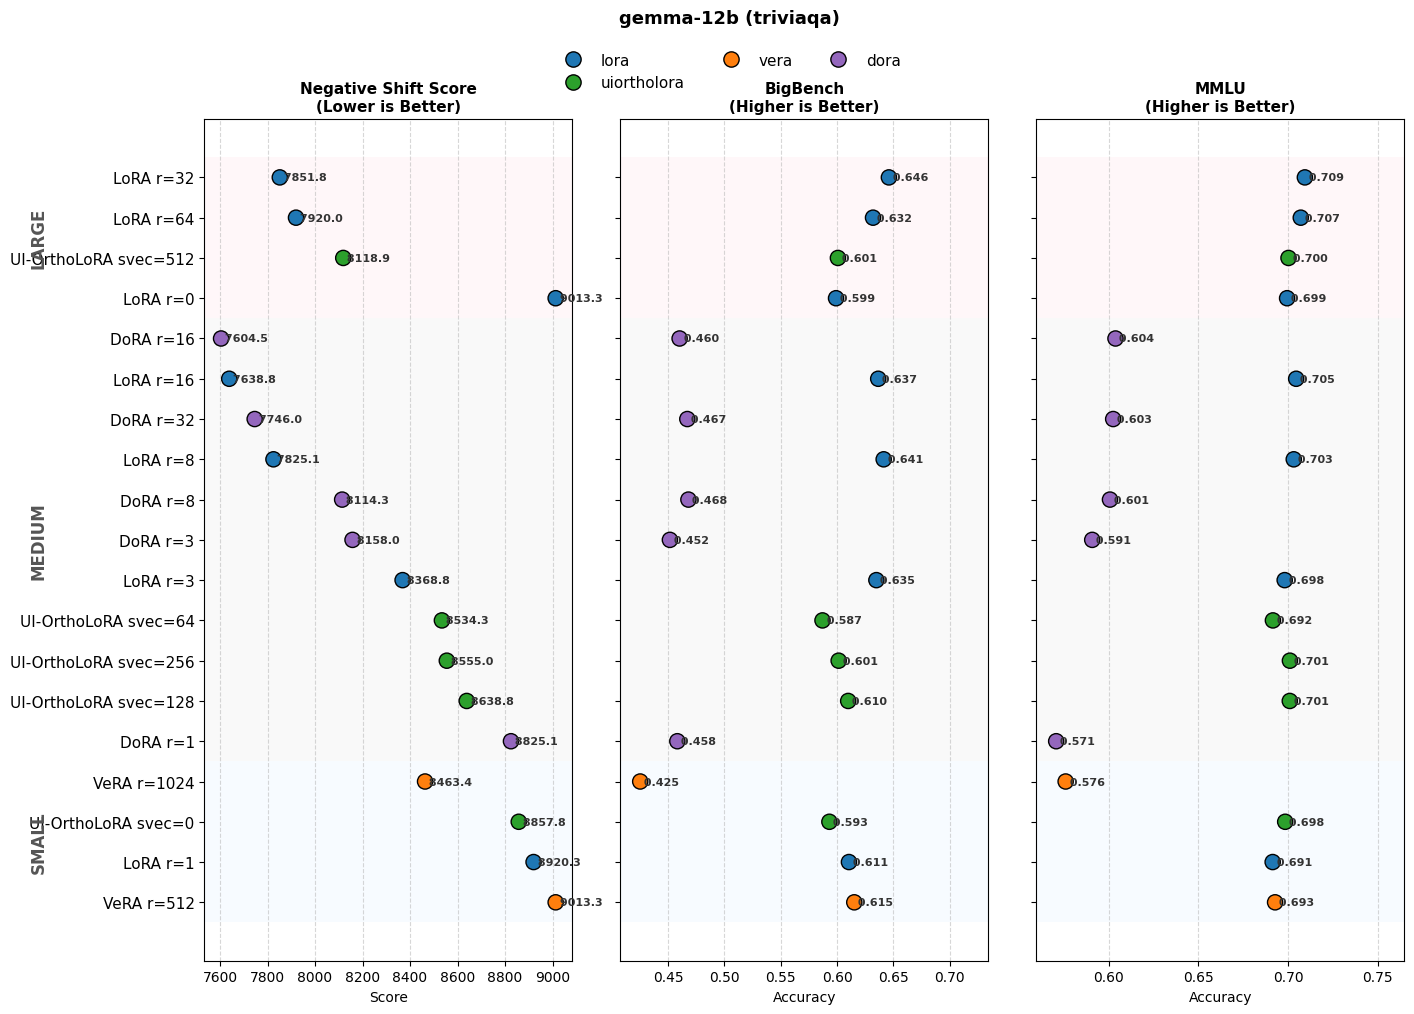

In [54]:
# ============================================================================
# CELL 6: GENERATE PLOT
# ============================================================================

plot_df = prepare_plot_df(best_per_config, TYPE_COLORS)
fig = plot_results(plot_df, TYPE_COLORS, BG_COLORS, PLOT_TITLE_PREFIX, FIGURE_SIZE)